In [1]:
#Import Necessary Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from imblearn.over_sampling import SMOTE
from sklearn.metrics import accuracy_score, classification_report, roc_auc_score, confusion_matrix

In [2]:
#Load Dataset
url = 'https://raw.githubusercontent.com/nikhilsthorat03/Telco-Customer-Churn/refs/heads/main/telco.csv'
df = pd.read_csv(url)

In [3]:
#Dataset Information
print(df.info())
print(df.head())
print(df['Churn'].value_counts())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 22 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   Unnamed: 0        7043 non-null   int64  
 1   customerID        7043 non-null   object 
 2   gender            7043 non-null   object 
 3   SeniorCitizen     7043 non-null   object 
 4   Partner           7043 non-null   object 
 5   Dependents        7043 non-null   object 
 6   tenure            7043 non-null   int64  
 7   PhoneService      7043 non-null   object 
 8   MultipleLines     7043 non-null   object 
 9   InternetService   7043 non-null   object 
 10  OnlineSecurity    7043 non-null   object 
 11  OnlineBackup      7043 non-null   object 
 12  DeviceProtection  7043 non-null   object 
 13  TechSupport       7043 non-null   object 
 14  StreamingTV       7043 non-null   object 
 15  StreamingMovies   7043 non-null   object 
 16  Contract          7043 non-null   object 


In [4]:
#Drop Unnecessary Columns
df.drop(columns=['Unnamed: 0'], axis=1, inplace=True)

In [5]:
#Convert TotalCharges to numeric
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'],errors='coerce')

In [6]:
#Check and handle missing values
df.isnull().sum()
df.fillna({'TotalCharges': df['TotalCharges'].median()}, inplace=True)

In [7]:
#Dataset Information after Cleaning
df.info()
df.head()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   object 
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,No,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,Stayed
1,5575-GNVDE,Male,No,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.50,Stayed
2,3668-QPYBK,Male,No,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Churned
3,7795-CFOCW,Male,No,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,Stayed
4,9237-HQITU,Female,No,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Churned


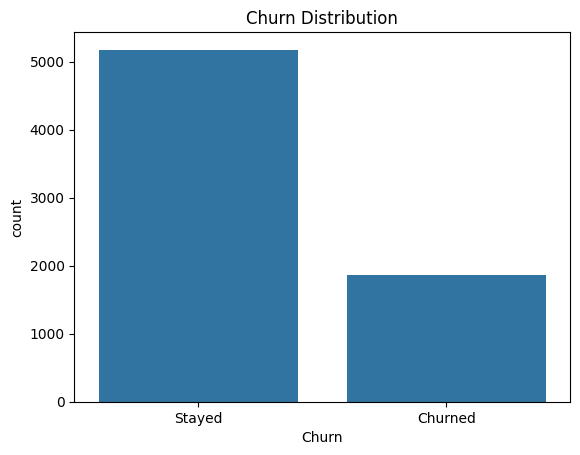

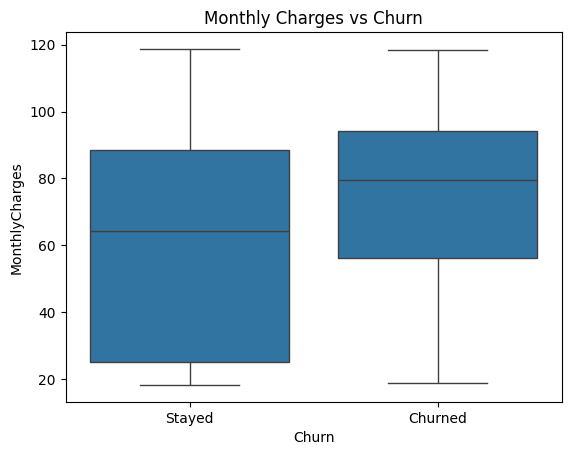

In [8]:
# Basic EDA (Exploration)

# Churn Distribution
sns.countplot(x='Churn', data=df)
plt.title("Churn Distribution")
plt.show()

# Monthly Charges vs Churn
sns.boxplot(x='Churn', y='MonthlyCharges', data=df)
plt.title("Monthly Charges vs Churn")
plt.show()

In [9]:
# Encoding (One-Hot Encoding)
df = pd.get_dummies(df, drop_first=True)
df.head()

,tenure,MonthlyCharges,TotalCharges,customerID_0003-MKNFE,customerID_0004-TLHLJ,customerID_0011-IGKFF,customerID_0013-EXCHZ,customerID_0013-MHZWF,customerID_0013-SMEOE,customerID_0014-BMAQU,...,StreamingTV_Yes,StreamingMovies_No internet service,StreamingMovies_Yes,Contract_One year,Contract_Two year,PaperlessBilling_Yes,PaymentMethod_Credit card (automatic),PaymentMethod_Electronic check,PaymentMethod_Mailed check,Churn_Stayed
0,1,29.85,29.85,False,False,False,False,False,False,False,...,False,False,False,False,False,True,False,True,False,True
1,34,56.95,1889.50,False,False,False,False,False,False,False,...,False,False,False,True,False,False,False,False,True,True
2,2,53.85,108.15,False,False,False,False,False,False,False,...,False,False,False,False,False,True,False,False,True,False
3,45,42.30,1840.75,False,False,False,False,False,False,False,...,False,False,False,True,False,False,False,False,False,True
4,2,70.70,151.65,False,False,False,False,False,False,False,...,False,False,False,False,False,True,False,True,False,False


In [10]:
#Define Feature and Target
X = df.drop('Churn_Stayed',axis=1)
y = df['Churn_Stayed']

In [11]:
#Split the dataset
X_train, X_test, y_train, y_test = train_test_split(X,y,test_size=0.2,random_state=42)

In [12]:
#Feature Scaling (for Logistic Regression)
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [13]:
#Handle Class Imbalance (SMOTE)
smote = SMOTE(random_state=42)

X_train_sm, y_train_sm = smote.fit_resample(X_train_scaled, y_train)

In [14]:
#Train the Model
lr = LogisticRegression(max_iter=2000)
lr.fit(X_train, y_train)

re = RandomForestClassifier(random_state=42)
re.fit(X_train,y_train)

/home/andyofficial2004/my-jupyter-env/lib/python3.11/site-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


RandomForestClassifier(random_state=42)

In [15]:
#Predict the model
y_pred_lr = lr.predict(X_test)
y_pred_re = re.predict(X_test)

In [16]:
#Evaluate the Regression model
print("Regression Accuracy:",accuracy_score(y_test,y_pred_lr))
print("\nClassification Report\n",classification_report(y_test,y_pred_lr))
print("ROC-AUC Score:",roc_auc_score(y_test,lr.predict_proba(X_test)[:,1]))

Regression Accuracy: 0.8161816891412349

Classification Report
               precision    recall  f1-score   support

       False       0.67      0.60      0.63       373
        True       0.86      0.89      0.88      1036

    accuracy                           0.82      1409
   macro avg       0.77      0.75      0.76      1409
weighted avg       0.81      0.82      0.81      1409

ROC-AUC Score: 0.8603400892274887


In [17]:
#Evaluate the Random Forest Model
print("Random Forest Accuracy:",accuracy_score(y_test,y_pred_re))
print("\nClassification Report\n",classification_report(y_test,y_pred_re))
print("ROC-AUC Score:",roc_auc_score(y_test,re.predict_proba(X_test)[:,1]))

Random Forest Accuracy: 0.8026969481902059

Classification Report
               precision    recall  f1-score   support

       False       0.69      0.46      0.55       373
        True       0.83      0.93      0.87      1036

    accuracy                           0.80      1409
   macro avg       0.76      0.69      0.71      1409
weighted avg       0.79      0.80      0.79      1409

ROC-AUC Score: 0.8542833335058537


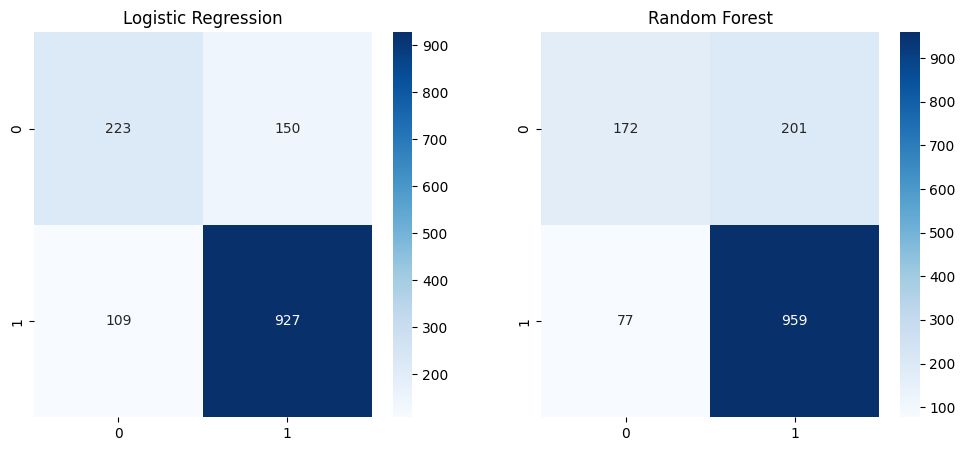

In [18]:
fig, axes = plt.subplots(1, 2, figsize=(12,5))

sns.heatmap(confusion_matrix(y_test, y_pred_lr), annot=True, fmt='d', cmap='Blues', ax=axes[0])
axes[0].set_title("Logistic Regression")

sns.heatmap(confusion_matrix(y_test, y_pred_re), annot=True, fmt='d', cmap='Blues', ax=axes[1])
axes[1].set_title("Random Forest")

plt.show()